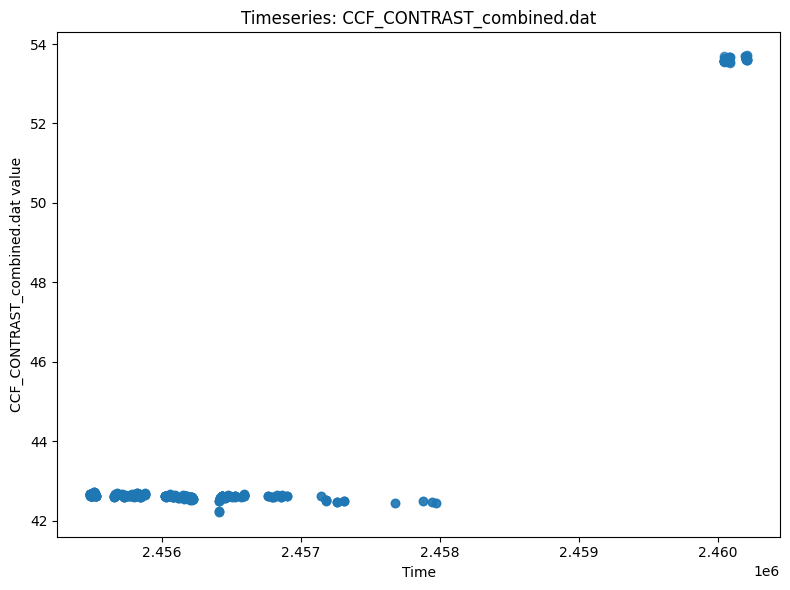

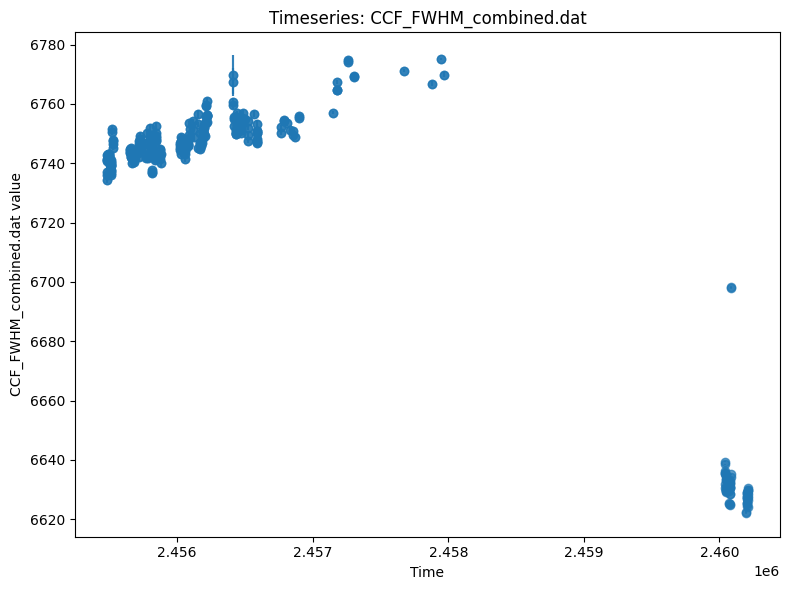

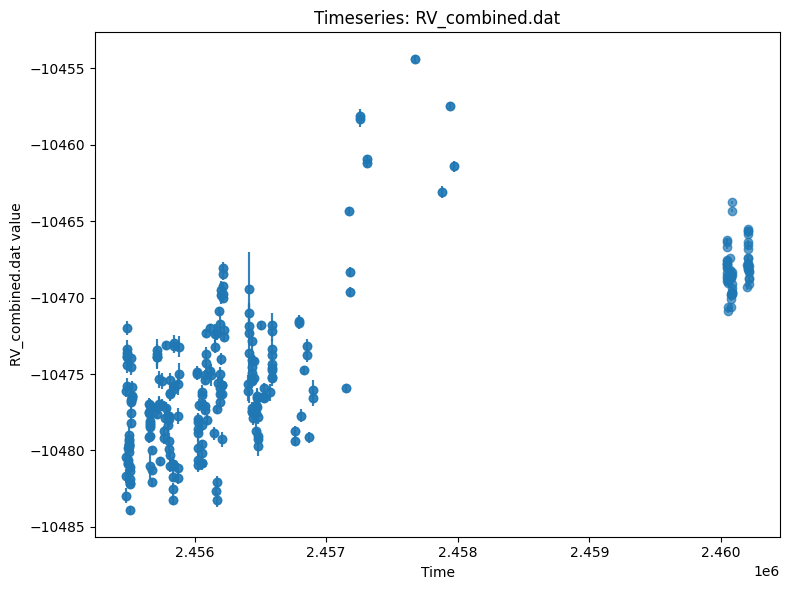

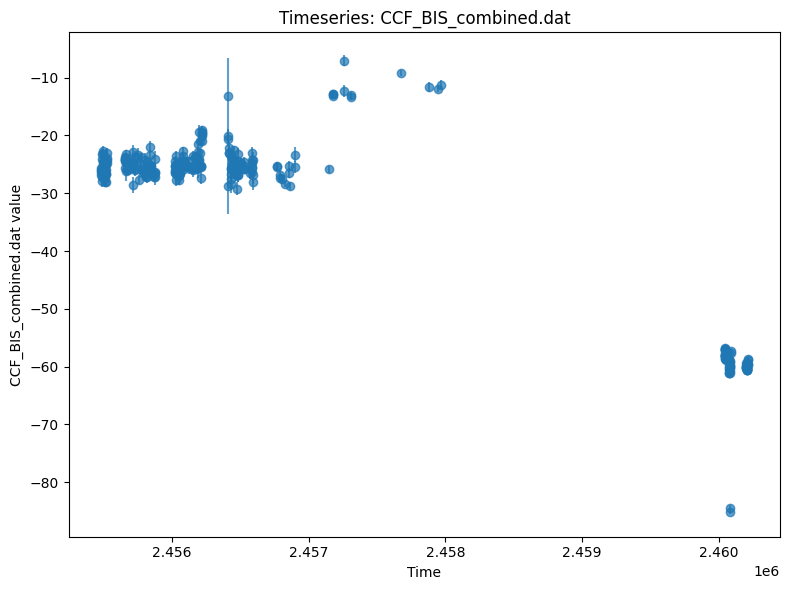

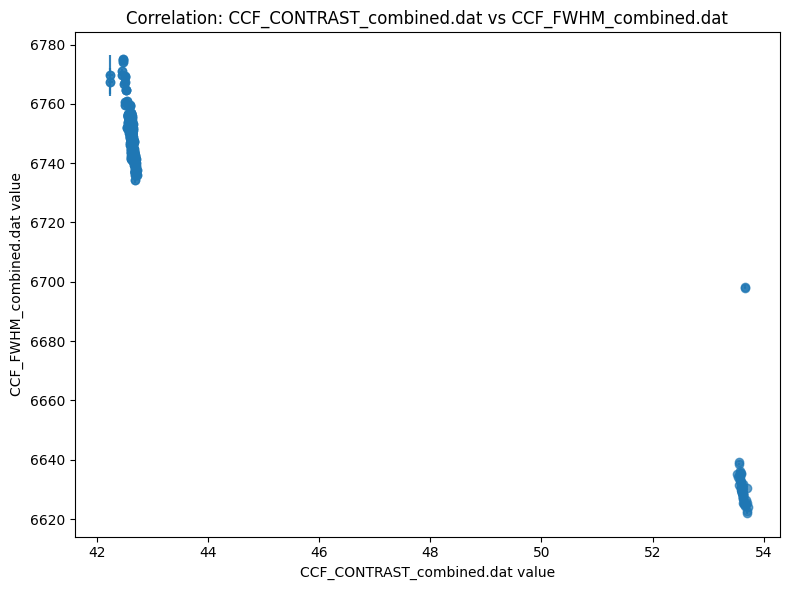

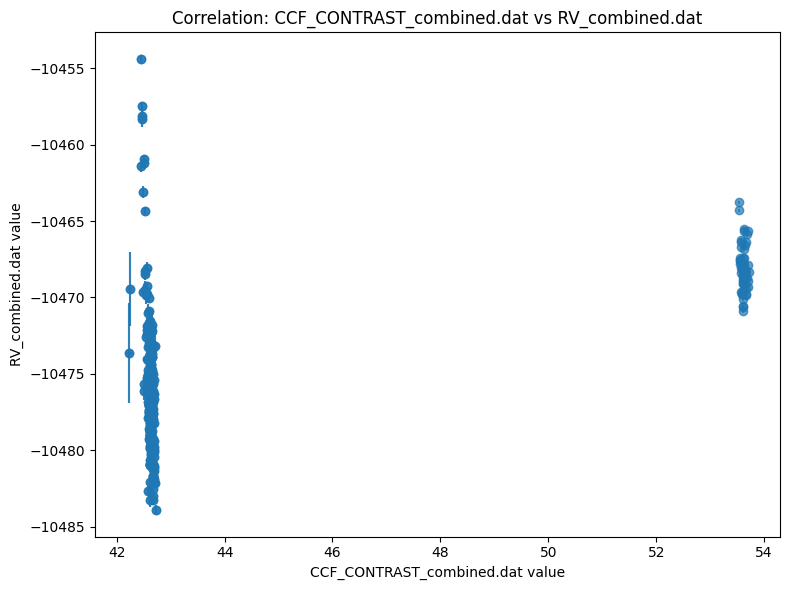

ValueError: 'x' and 'y' must have the same size

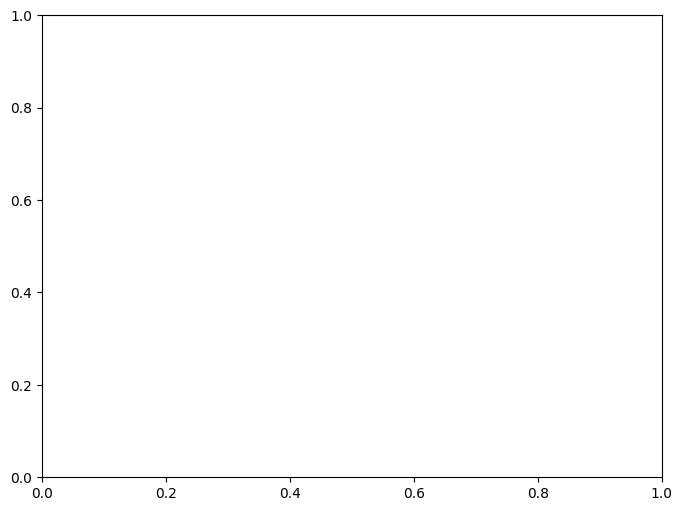

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

# Path to the ESPRESSO directory
# dir = 'ESPRESSO'
dir = 'Combined'

# Get all files in the directory
data_files = glob.glob(os.path.join(dir, '*'))

# Dictionary to store data for each file
data_dict = {}

# Read and store data for each file
for file_path in data_files:
    try:
        # Try to read the file as whitespace-delimited, skip empty/comment lines
        data = []
        with open(file_path, 'r') as f:
            for line in f:
                if line.strip() and not line.strip().startswith('#'):
                    data.append([float(x) for x in line.strip().split()])
        if len(data) == 0:
            continue
        data = np.array(data)
        # Store as dict: key = filename, value = dict with time, value, yerr
        file_key = os.path.basename(file_path)
        entry = {
            'time': data[:, 0],
            'value': data[:, 1]
        }
        if data.shape[1] > 2:
            entry['yerr'] = data[:, 2]
        else:
            entry['yerr'] = None
        data_dict[file_key] = entry
    except Exception as e:
        print(f"Could not process {file_path}: {e}")

# Plot timeseries for each variable
for key, d in data_dict.items():
    plt.figure(figsize=(8, 6))
    if d['yerr'] is not None:
        plt.errorbar(d['time'], d['value'], yerr=d['yerr'], fmt='o', alpha=0.7)
    else:
        plt.plot(d['time'], d['value'], 'o', alpha=0.7)
    plt.xlabel("Time")
    plt.ylabel(f"{key} value")
    plt.title(f"Timeseries: {key}")
    plt.tight_layout()
    plt.show()

# Now, plot correlations between all pairs of variables (files)
file_keys = list(data_dict.keys())
n = len(file_keys)

for i in range(n):
    for j in range(i+1, n):
        key1 = file_keys[i]
        key2 = file_keys[j]
        d1 = data_dict[key1]
        d2 = data_dict[key2]
        # Find common times
        t1 = d1['time']
        t2 = d2['time']
        # Use intersection of times
        common_times = np.intersect1d(t1, t2)
        if len(common_times) == 0:
            continue
        # Get indices for common times
        idx1 = np.isin(t1, common_times)
        idx2 = np.isin(t2, common_times)
        v1 = d1['value'][idx1]
        v2 = d2['value'][idx2]
        # Optionally, get errors if available
        yerr1 = d1['yerr'][idx1] if d1['yerr'] is not None else None
        yerr2 = d2['yerr'][idx2] if d2['yerr'] is not None else None

        plt.figure(figsize=(8, 6))
        if yerr1 is not None and yerr2 is not None:
            plt.errorbar(v1, v2, xerr=yerr1, yerr=yerr2, fmt='o', alpha=0.7)
        else:
            plt.plot(v1, v2, 'o', alpha=0.7)
        plt.xlabel(f"{key1} value")
        plt.ylabel(f"{key2} value")
        plt.title(f"Correlation: {key1} vs {key2}")
        plt.tight_layout()
        plt.show()
